-> Loading speech file
  • Fs = 48000 Hz  |  Samples = 353,280
-> PCM encoding (8-bit mid-rise)
  • Bit-stream length = 2,826,240 bits
-> Raised-cosine pulse shaping
  • Waveform samples = 56,524,960  |  Line rate = 20.0 kHz
-> Eye diagram of clean signal


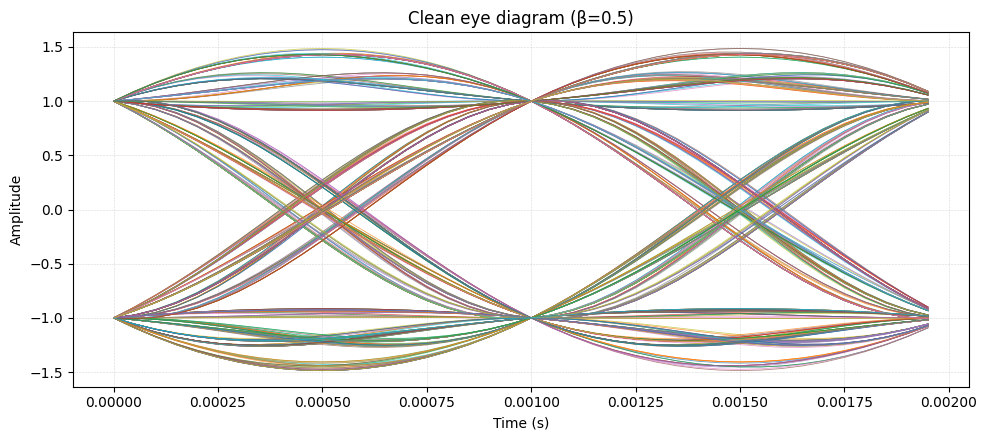

-> Adding AWGN  σ² = 0.5


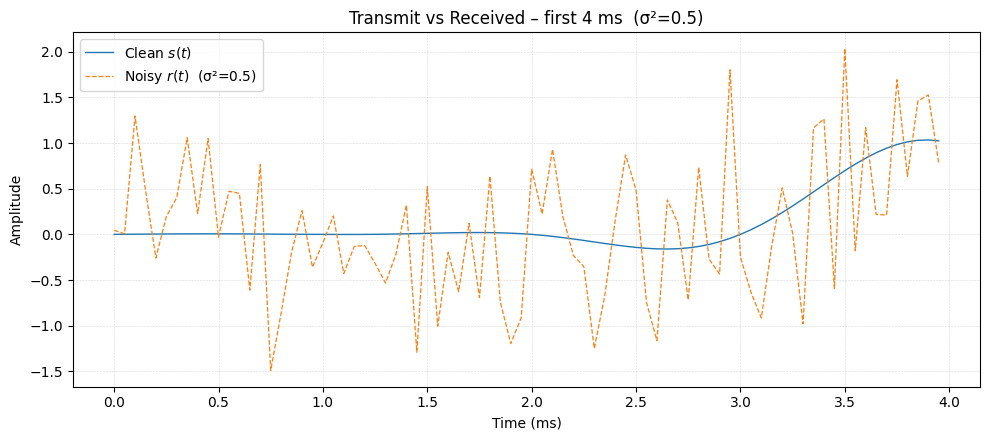

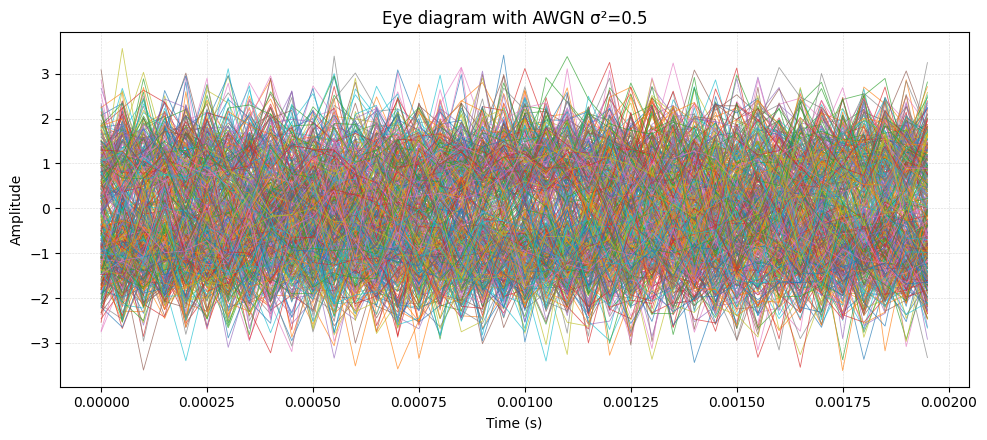

-> Adding AWGN  σ² = 2.0


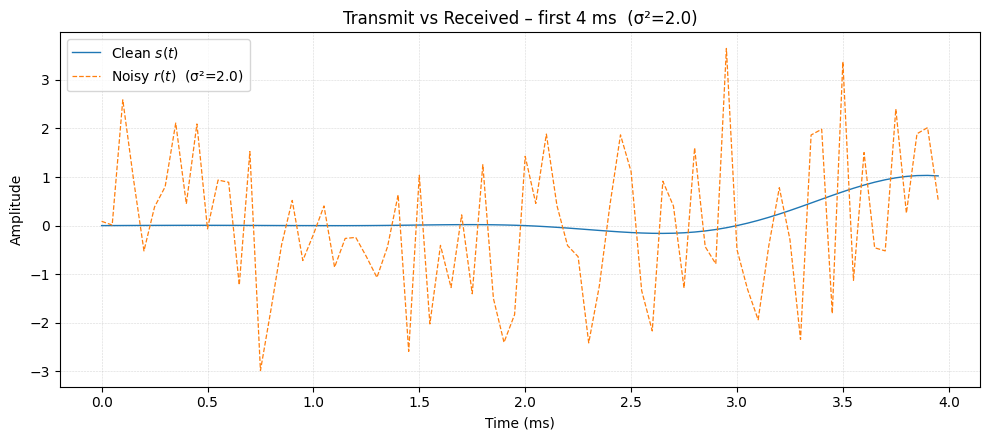

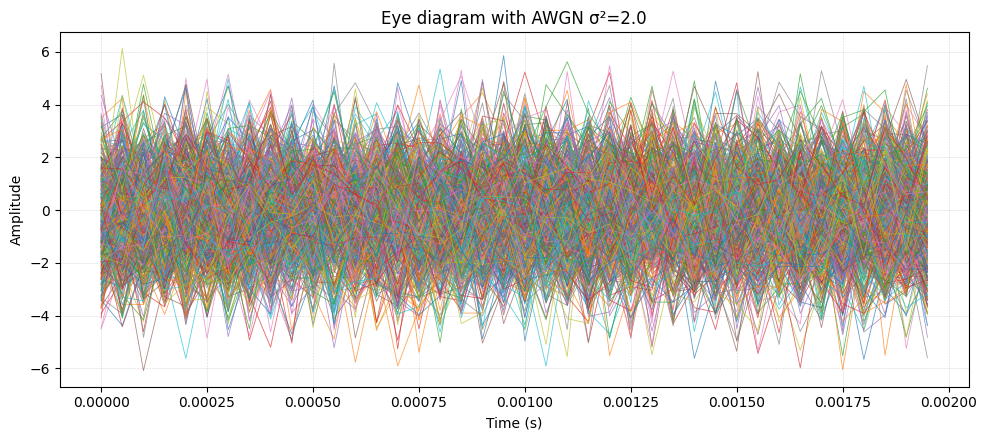

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile

def PcmEncode(Signal, Levels=256):
    X = Signal.astype(np.float64)
    MinVal, MaxVal = X.min(), X.max()
    Step = (MaxVal - MinVal) / Levels
    Indices = np.clip(((X - MinVal) / Step).astype(int), 0, Levels - 1)
    BitsPerSample = int(np.log2(Levels))
    Fmt = "{:0" + str(BitsPerSample) + "b}"
    return np.fromiter((Bit for i in Indices for Bit in Fmt.format(i)), dtype="U1")

def RaisedCosinePulse(Beta, Tb, Oversample, SpanSymbols=8):
    T = np.arange(-SpanSymbols / 2, SpanSymbols / 2 + 1 / Oversample, 1 / Oversample) * Tb
    if Beta == 0.0:
        P = np.sinc(T / Tb)
    else:
        SincPart = np.sinc(T / Tb)
        CosPart  = np.cos(np.pi * Beta * T / Tb)
        Denom    = 1 - (2 * Beta * T / Tb) ** 2
        P        = np.empty_like(T)
        Reg      = ~np.isclose(Denom, 0.0)
        P[Reg]   = SincPart[Reg] * CosPart[Reg] / Denom[Reg]
        P[~Reg]  = (np.pi / 4) * np.sinc(1 / (2 * Beta))
    return P / np.max(np.abs(P))

def PolarImpulseTrain(Bits, Oversample):
    Polarity           = np.where(Bits == "1", 1.0, -1.0)
    Train              = np.zeros(len(Polarity) * Oversample, dtype=float)
    Train[::Oversample] = Polarity
    return Train

def TransmitRc(Bits, Tb=1e-3, Beta=0.5, Oversample=20, SpanSymbols=8):
    Pulse     = RaisedCosinePulse(Beta, Tb, Oversample, SpanSymbols)
    Impulses  = PolarImpulseTrain(Bits, Oversample)
    S         = np.convolve(Impulses, Pulse, mode="full").astype(np.float32)
    FsLine    = Oversample / Tb
    return S, FsLine

def AddAwgn(Signal, NoiseVar, Seed=2022484):
    Rng   = np.random.default_rng(Seed)
    Noise = Rng.normal(0.0, np.sqrt(NoiseVar), size=Signal.shape)
    return (Signal + Noise).astype(np.float32)

def EyeDiagram(Signal, Tb, Oversample, SpanBits=2, Traces=500, Title="Eye diagram"):
    SampSym   = Oversample
    SpanSamps = SpanBits * SampSym
    Starts    = np.arange(0, len(Signal) - SpanSamps, SampSym)
    Rng       = np.random.default_rng(2022484)
    Picks     = Rng.choice(Starts, size=min(Traces, len(Starts)), replace=False)
    TEye      = np.linspace(0, SpanBits * Tb, SpanSamps, endpoint=False)
    plt.figure(figsize=(10, 4.5))
    for St in Picks:
        plt.plot(TEye, Signal[St : St + SpanSamps], lw=0.6, alpha=0.7)
    plt.title(Title)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.grid(ls="--", lw=0.4, alpha=0.5)
    plt.tight_layout()
    plt.show()

AudioPath   = r"X:\Projects\PCS\Assignment 2\2022484_Shreyansh Seth.wav"
Tb          = 1e-3
Oversample  = 20
Beta        = 0.5
Sigma2List  = [0.5, 2.0]

print("-> Loading speech file")
FsAudio, Speech = wavfile.read(AudioPath)
if Speech.ndim > 1:
    Speech = Speech.mean(axis=1)
print(f"  • Fs = {FsAudio} Hz  |  Samples = {len(Speech):,}")

print("-> PCM encoding (8-bit mid-rise)")
Bits = PcmEncode(Speech, Levels=256)
print(f"  • Bit-stream length = {len(Bits):,} bits")

print("-> Raised-cosine pulse shaping")
S, FsLine = TransmitRc(Bits, Tb, Beta, Oversample)
print(f"  • Waveform samples = {len(S):,}  |  Line rate = {FsLine/1e3:.1f} kHz")

print("-> Eye diagram of clean signal")
EyeDiagram(S, Tb, Oversample, Title="Clean eye diagram (β=0.5)")

Time = np.arange(len(S)) / FsLine
Zoom = slice(0, int(0.004 * FsLine))

for Sigma2 in Sigma2List:
    print(f"-> Adding AWGN  σ² = {Sigma2}")
    R = AddAwgn(S, Sigma2)
    
    plt.figure(figsize=(10, 4.5))
    plt.plot(Time[Zoom] * 1e3, S[Zoom], lw=1.0, label="Clean $s(t)$")
    plt.plot(Time[Zoom] * 1e3, R[Zoom], "--", lw=0.9,
             label=f"Noisy $r(t)$  (σ²={Sigma2})")
    plt.title(f"Transmit vs Received – first 4 ms  (σ²={Sigma2})")
    plt.xlabel("Time (ms)")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(ls="--", lw=0.4, alpha=0.5)
    plt.tight_layout()
    plt.show()
    EyeDiagram(R, Tb, Oversample, Title=f"Eye diagram with AWGN σ²={Sigma2}")

# Problem 5 Report  
**Raised-Cosine Pulse Shaping, AWGN Channel, and Eye Diagrams**

---

## 1. Introduction  
In this problem we replace the rectangular pulses of a polar NRZ waveform with raised-cosine pulses, generate a transmit waveform \(s(t)\), pass it through a noisy channel to obtain \(r(t)\), and examine how different noise levels affect both the time-domain waveform and the eye diagram.

---

## 2. Implementation Details  

- **Source signal**  
  – 8-bit mid-rise PCM encoding of a spoken-word audio file sampled at 48 kHz  
- **Bit-stream**  
  – Derived by uniform mid-rise quantization into 256 levels  
- **Pulse shaping**  
  – Raised-cosine filter with roll-off factor 0.5  
  – Symbol period of 1 ms, oversampling factor of 20, filter span of 8 symbols  
- **Line waveform**  
  – Convolution of the impulse train with the raised-cosine pulse  
  – Resulting line rate: 20 kHz  
- **Channel model**  
  – Additive white Gaussian noise (AWGN) with two noise-variance settings:  
    - Low noise: variance = 0.5  
    - High noise: variance = 2.0  
- **Eye-diagram parameters**  
  – Plot span of 2 symbol intervals, up to 500 random traces per diagram

---

## 3. Results  

### 3.1 Clean Transmit Eye Diagram  
- The “eye” is wide open  
- Distinct upper and lower levels with clear zero crossings  
- Minimal trace overlap  

---

### 3.2 Transmit vs. Received Waveforms (first 4 ms)  

| Noise variance | Time-domain plot (first 4 ms) |
|:--------------:|:------------------------------|
| **0.5**        |  |
| **2.0**        |  |

- **Low variance (0.5)**  
  - Received waveform closely follows the clean transmit signal  
  - Small random deviations around each symbol level  

- **High variance (2.0)**  
  - Large amplitude excursions—many samples stray well beyond the original symbol levels  
  - Intervals become much noisier and less recognizable

---

### 3.3 Received Eye Diagrams  

| Noise variance | Eye diagram |
|:--------------:|:-----------:|
| **0.5**        |  |
| **2.0**        |  |

- **Low variance (0.5)**  
  - The eye remains open but the trace boundaries are fuzzier  
  - Some noise around the decision point, but symbol intervals are still separable  

- **High variance (2.0)**  
  - The eye nearly closes—upper and lower traces overlap heavily  
  - Decision threshold is ambiguous and timing jitter is pronounced  

---

## 4. Observations and Discussion  

- **Noise impact on waveform**  
  – Increasing noise variance produces larger deviations in the received signal, making symbol levels harder to distinguish  
- **Eye-diagram closure**  
  – As noise grows, the vertical opening shrinks (reduced noise margin) and the horizontal opening narrows (increased timing jitter)  
- **System performance**  
  – A well-shaped pulse (raised cosine) still suffers from AWGN; eye-diagram analysis directly reveals SNR-related limits on reliable symbol recovery  

---

## 5. Conclusion  

Raised-cosine pulse shaping provides controlled bandwidth and clear symbol separation in the absence of noise. Passing the same waveform through an AWGN channel shows that even modest noise variance begins to blur symbol levels, and high noise variance can close the eye diagram entirely, signaling a breakdown in reliable detection.  
